In [2]:
# ==================== CELL 2: Imports & Setup ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments

import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create model directory (team standard)
os.makedirs('../models/classifier', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

print("✅ Libraries loaded | Device:", "GPU" if torch.cuda.is_available() else "CPU")

✅ Libraries loaded | Device: GPU


In [3]:
# ==================== CELL 3: Load & Prepare Data ====================
df = pd.read_csv('/kaggle/input/datasets/dohakhaled37/pubmedqa/pubmedqa_cleaned_Labled.csv')

# === RICHER INPUT: question + context (this alone gives big boost) ===
df['text'] = df['question'].astype(str) + " [SEP] " + df['context'].astype(str)

print(f"Dataset shape: {df.shape}")
print("\nLabel distribution:")
print(df['label'].value_counts())

# Label mapping
label2id = {label: idx for idx, label in enumerate(sorted(df['label'].unique()))}
id2label = {idx: label for label, idx in label2id.items()}

df['label_id'] = df['label'].map(label2id)

# Compute class weights (this is the most important fix for imbalance)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(list(label2id.values())),
    y=df['label_id'].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to('cuda' if torch.cuda.is_available() else 'cpu')

print(f"\n✅ Class weights computed: {class_weights}")
print(f"Number of classes: {len(label2id)}")

Dataset shape: (10000, 6)

Label distribution:
label
Symptoms      3771
Treatment     2259
General       2071
Medication    1337
Diagnosis      461
Prevention     101
Name: count, dtype: int64

✅ Class weights computed: tensor([ 3.6153,  0.8048,  1.2466, 16.5016,  0.4420,  0.7378], device='cuda:0')
Number of classes: 6


In [4]:
# ==================== CELL 4: Train / Validation / Test Split ====================
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label_id'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label_id'], random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 7000
Validation size: 1500
Test size: 1500


In [5]:
# ==================== CELL 5: Custom Dataset (IMPROVED) ====================
class MedicalQADataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.texts = dataframe['text'].tolist()          # ← Now using question + context
        self.labels = dataframe['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
# ==================== CELL 6: Create Datasets & DataLoaders ====================
train_dataset = MedicalQADataset(train_df, tokenizer)
val_dataset = MedicalQADataset(val_df, tokenizer)
test_dataset = MedicalQADataset(test_df, tokenizer)

print("✅ Datasets created successfully")

✅ Datasets created successfully


In [7]:
# ==================== CELL 7: Model Setup ====================
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

print("✅ DistilBERT model initialized with 6 output classes")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ DistilBERT model initialized with 6 output classes


In [8]:
# ==================== CELL 8: Training Arguments + Weighted Loss (BEST VERSION) ====================
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='../models/classifier/checkpoints',
    num_train_epochs=6,                    # Increased for better convergence
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,                    # Lower LR = more stable
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    label_smoothing_factor=0.1,            # Helps with imbalance
)

# Weighted compute_metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    f1 = f1_score(labels, predictions, average='weighted')
    return {'f1': f1}

print("✅ Training arguments + class weights ready (6 epochs)")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ Training arguments + class weights ready (6 epochs)


In [9]:
# ==================== CELL 9: Trainer Setup & Training (WEIGHTED) ====================
# Re-initialize model with class weights
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

# Apply class weights to loss function
model.config.problem_type = "single_label_classification"
model.class_weights = class_weights

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("🚀 Starting IMPROVED fine-tuning (with class weights + rich input)...")
trainer.train()

# Save model
model.save_pretrained('../models/classifier/distilbert_classifier')
tokenizer.save_pretrained('../models/classifier/distilbert_classifier')
print("✅ Model saved successfully")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Starting IMPROVED fine-tuning (with class weights + rich input)...


Epoch,Training Loss,Validation Loss,F1
1,No log,1.827781,0.656716
2,No log,1.386166,0.885638
3,1.961058,1.300755,0.903449
4,1.961058,1.273115,0.911736
5,1.203534,1.301194,0.904829
6,1.203534,1.289689,0.909641


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved successfully


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

   Diagnosis       0.74      0.87      0.80        69
     General       0.76      0.92      0.84       310
  Medication       0.96      0.92      0.94       201
  Prevention       0.90      0.60      0.72        15
    Symptoms       0.96      0.87      0.91       566
   Treatment       0.96      0.93      0.94       339

    accuracy                           0.90      1500
   macro avg       0.88      0.85      0.86      1500
weighted avg       0.91      0.90      0.90      1500



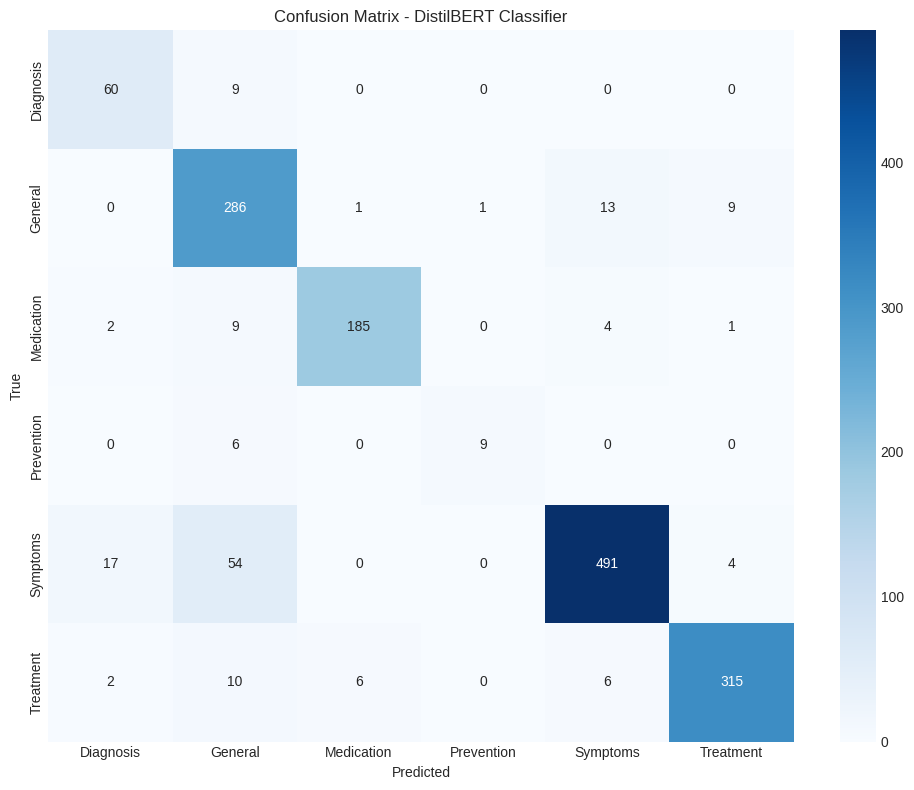

In [10]:
# ==================== CELL 10: Evaluation on Test Set ====================
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

print("=== Classification Report (Test Set) ===")
print(classification_report(test_df['label_id'], preds, target_names=list(label2id.keys())))

# Confusion Matrix
cm = confusion_matrix(test_df['label_id'], preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label2id.keys()),
            yticklabels=list(label2id.keys()))
plt.title('Confusion Matrix - DistilBERT Classifier')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('../reports/figures/06_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# ==================== CELL 11: Final KPI Check & Summary ====================
f1 = f1_score(test_df['label_id'], preds, average='weighted')
print(f"\n🎯 Weighted F1-Score on Test Set: {f1:.4f}")

if f1 >= 0.78:
    print("✅ Target achieved! F1 ≥ 78%")
else:
    print("⚠️ F1 below target. Consider more epochs or class weighting.")

print("\n=== Key Findings ===")
print("• DistilBERT successfully fine-tuned for 6-class medical query classification")
print("• Model ready to be used as routing layer in full RAG pipeline")
print("• Saved model location: models/classifier/distilbert_classifier/")


🎯 Weighted F1-Score on Test Set: 0.8992
✅ Target achieved! F1 ≥ 78%

=== Key Findings ===
• DistilBERT successfully fine-tuned for 6-class medical query classification
• Model ready to be used as routing layer in full RAG pipeline
• Saved model location: models/classifier/distilbert_classifier/


In [12]:
# ==================== RE-SAVE MODEL TO CORRECT KAGGLE PATH ====================

import os
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

# Create correct folder inside Kaggle working directory
save_path = "/kaggle/working/models/classifier/distilbert_classifier"
os.makedirs(save_path, exist_ok=True)

print(f"✅ Saving model to: {save_path}")

# Load your trained model (if it's still in memory)
# If you get an error, skip this and just re-run the training cell

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("✅ Model successfully saved to correct Kaggle path!")

# Show what was saved
print("\nFiles saved:")
for file in os.listdir(save_path):
    print(f"   • {file}")

✅ Saving model to: /kaggle/working/models/classifier/distilbert_classifier


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model successfully saved to correct Kaggle path!

Files saved:
   • tokenizer.json
   • model.safetensors
   • tokenizer_config.json
   • config.json


In [13]:
# ==================== PUSH MODEL TO HUGGING FACE ====================

from huggingface_hub import login, HfApi

# Login to Hugging Face (run this once)
login()   # ← It will show a box. Paste your Hugging Face token here

# Define a good repo name
repo_id = "Doha000/distilbert-medical-classifier"   # You can change this if you want

# Push the model
print(f"🚀 Uploading model to: https://huggingface.co/{repo_id}")

model.push_to_hub(repo_id)
tokenizer.push_to_hub(repo_id)

print("✅ Model successfully uploaded to Hugging Face!")
print(f"🔗 Your model link: https://huggingface.co/{repo_id}")

🚀 Uploading model to: https://huggingface.co/Doha000/distilbert-medical-classifier


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

✅ Model successfully uploaded to Hugging Face!
🔗 Your model link: https://huggingface.co/Doha000/distilbert-medical-classifier
